In [2]:
import os
import random
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from sympy import rotations
from tqdm import tqdm

from glacierview import config, preprocess
from glacierview import rasters as read  # was helpers/read.py
from glacierview import viz as explore  # was helpers/explore.py

In [3]:
data_label = "localized_time_series_for_training_c02_t1_l2"
glacier_view_dir = str(config.REPO_ROOT)
glaciers_dir = os.path.join(glacier_view_dir,"src","earth_engine","data","ee_landing_zone",data_label, "landsat")

In [4]:
glims_ids = [f for f in os.listdir(glaciers_dir) if f != ".DS_Store"]
min_dict = {}
max_dict = {}
for i in range(20):
    min_dict[i] = []
    max_dict[i] = []
for glims_id in tqdm(glims_ids):
    file_names = os.listdir(os.path.join(glaciers_dir,glims_id))
    file_names = [f for f in file_names if f.endswith(".tif")]
    for file_name in file_names:
        if file_name.split("_")[2] != "L8":
            continue
        with rasterio.open(os.path.join(glaciers_dir,glims_id,file_name)) as src:
            raster = src.read()
        for i in range(raster.shape[0]):
            min_dict[i].append(raster[i,:,:].min())
            max_dict[i].append(raster[i,:,:].max())

  3%|████▎                                                                                                                                  | 573/18093 [00:17<08:53, 32.85it/s]


KeyboardInterrupt: 

In [ ]:
i = 12
fig, ax = plt.subplots(1,2)
ax[0].hist(min_dict[i])
ax[1].hist(max_dict[i])
plt.show()

In [1]:
for file_name, written_training_image in written_training_images.items():
    counter = 0
    band_labels = ['blue','green','red','nir','swir','thermal', 'dem','mask']
    device = file_name.split("_")[2]
    if device != "L8":
        continue
    fig, ax = plt.subplots(2,4, figsize = (10,5))
    fig.suptitle(file_name, fontsize=16)
    for i in range(2):
        for j in range(4):
            ax[i,j].imshow(written_training_image[:,:,counter])
            ax[i,j].set_title(band_labels[counter])
            counter += 1
    plt.show()

NameError: name 'written_training_images' is not defined

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
df = pd.read_csv("/Users/mattw/Downloads/7697706f-0cfd-4b92-9bff-32f6d8931dc0.csv")
df.head()

,geog_area_rollup,_col1,number_of_files,number_of_glims_ids
0,South America,1984-01-01,46,44
1,Europe,1984-01-01,300,50
2,North America,1984-01-01,371,48
3,Caucausus,1984-01-01,159,50
4,North America,1985-01-01,294,44


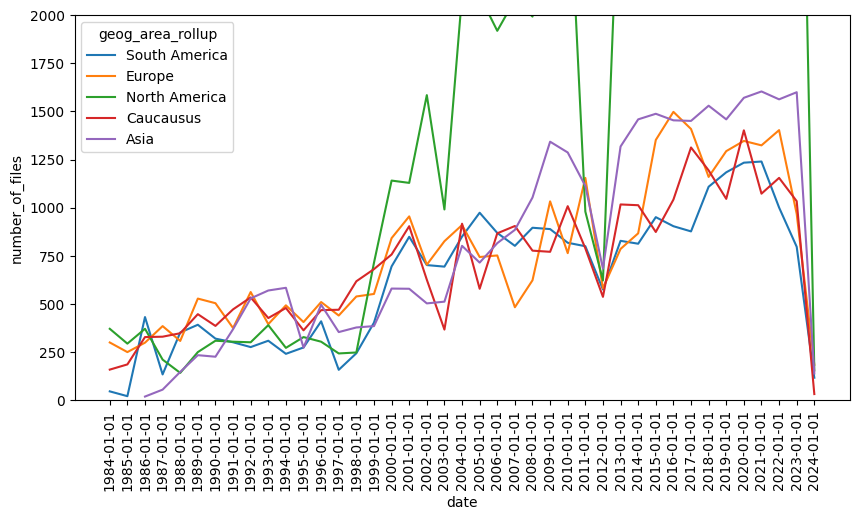

In [7]:
plt.figure(figsize=(10,5))
sns.lineplot(x="_col1", y="number_of_files", data = df, hue = "geog_area_rollup")
plt.xticks(rotation=90)
plt.xlabel("date")
plt.ylim((0,2000))
plt.show()

In [15]:
df = pd.read_csv("/Users/mattw/Downloads/3293db2e-d0e9-4a21-92c0-06ba9749c0fd.csv")

,glims_id,geog_area_rollup,_col2,number_of_files
0,G022083E70150N,Europe,1984-01-01,6
1,G007807E46481N,Europe,1984-01-01,3
2,G043772E42828N,Caucausus,1984-01-01,2
3,G043844E42752N,Caucausus,1984-01-01,2
4,G041626E43230N,Caucausus,1984-01-01,3
